In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/customer_support_tickets_1540.csv")

In [4]:
df.head()

,ticket_id,ticket,category,priority
0,1,I am contacting support because money was dedu...,Payment Issue,Medium
1,2,I am contacting support because i cannot compl...,Technical Issue,Medium
2,3,I need support with this: the payment was reje...,Payment Issue,High
3,4,I am having trouble because I need help with a...,Payment Issue,High
4,5,I need support with this: The item in my order...,Order Issue,Low


In [5]:
df.shape

(1540, 4)

In [6]:
df.columns

Index(['ticket_id', 'ticket', 'category', 'priority'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ticket_id  1540 non-null   int64 
 1   ticket     1540 non-null   object
 2   category   1540 non-null   object
 3   priority   1540 non-null   object
dtypes: int64(1), object(3)
memory usage: 48.3+ KB


In [8]:
df.isna().sum()

,0
ticket_id,0
ticket,0
category,0
priority,0


In [9]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["category"].value_counts()

,count
category,
Payment Issue,220
Technical Issue,220
Order Issue,220
Subscription,220
Delivery,220
Refund,220
Account Issue,220


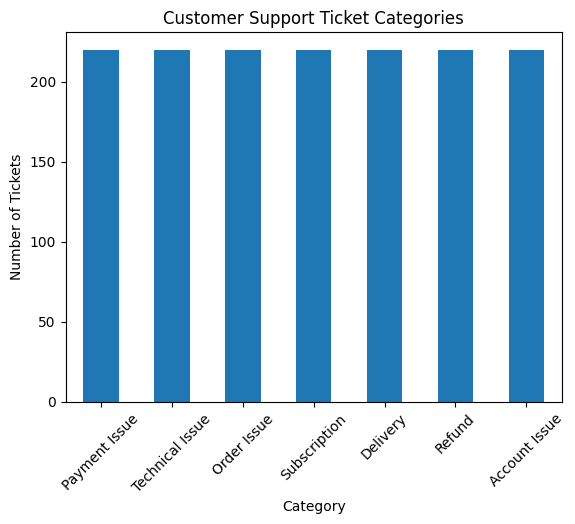

In [12]:
df["category"].value_counts().plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Number of Tickets")
plt.title("Customer Support Ticket Categories")
plt.xticks(rotation=45)
plt.show()

In [13]:
df["priority"].value_counts()

,count
priority,
Medium,631
High,606
Low,303


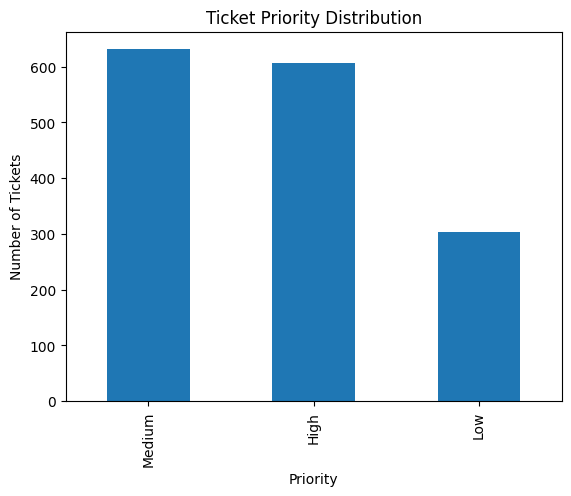

In [14]:
df["priority"].value_counts().plot(kind="bar")
plt.xlabel("Priority")
plt.ylabel("Number of Tickets")
plt.title("Ticket Priority Distribution")
plt.show()

In [15]:
X = df["ticket"]
y = df["category"]
print(X.head())

0    I am contacting support because money was dedu...
1    I am contacting support because i cannot compl...
2    I need support with this: the payment was reje...
3    I am having trouble because I need help with a...
4    I need support with this: The item in my order...
Name: ticket, dtype: object


In [16]:
print(y.head())

0      Payment Issue
1    Technical Issue
2      Payment Issue
3      Payment Issue
4        Order Issue
Name: category, dtype: object


In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [19]:
print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 1232
Testing data: 308


TF-IDF = Term Frequency – Inverse Document Frequency

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(lowercase=True,stop_words="english")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [21]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(1232, 107)
(308, 107)


In [24]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
print(y_pred)

['Refund' 'Account Issue' 'Payment Issue' 'Delivery' 'Delivery'
 'Payment Issue' 'Account Issue' 'Delivery' 'Subscription' 'Delivery'
 'Account Issue' 'Payment Issue' 'Technical Issue' 'Delivery'
 'Account Issue' 'Order Issue' 'Subscription' 'Subscription' 'Refund'
 'Payment Issue' 'Technical Issue' 'Delivery' 'Technical Issue'
 'Account Issue' 'Account Issue' 'Technical Issue' 'Refund'
 'Payment Issue' 'Refund' 'Order Issue' 'Technical Issue' 'Payment Issue'
 'Refund' 'Technical Issue' 'Subscription' 'Technical Issue' 'Refund'
 'Subscription' 'Subscription' 'Delivery' 'Payment Issue' 'Account Issue'
 'Order Issue' 'Order Issue' 'Refund' 'Delivery' 'Technical Issue'
 'Refund' 'Delivery' 'Subscription' 'Payment Issue' 'Technical Issue'
 'Order Issue' 'Refund' 'Refund' 'Subscription' 'Subscription'
 'Payment Issue' 'Delivery' 'Technical Issue' 'Refund' 'Refund' 'Refund'
 'Subscription' 'Order Issue' 'Subscription' 'Order Issue'
 'Technical Issue' 'Subscription' 'Order Issue' 'Delivery' '

In [27]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

  Account Issue       1.00      1.00      1.00        44
       Delivery       1.00      0.98      0.99        44
    Order Issue       0.98      1.00      0.99        44
  Payment Issue       1.00      1.00      1.00        44
         Refund       1.00      1.00      1.00        44
   Subscription       1.00      1.00      1.00        44
Technical Issue       1.00      1.00      1.00        44

       accuracy                           1.00       308
      macro avg       1.00      1.00      1.00       308
   weighted avg       1.00      1.00      1.00       308



In [30]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("confusion_matrix:\n",cm)

confusion_matrix:
 [[44  0  0  0  0  0  0]
 [ 0 43  1  0  0  0  0]
 [ 0  0 44  0  0  0  0]
 [ 0  0  0 44  0  0  0]
 [ 0  0  0  0 44  0  0]
 [ 0  0  0  0  0 44  0]
 [ 0  0  0  0  0  0 44]]


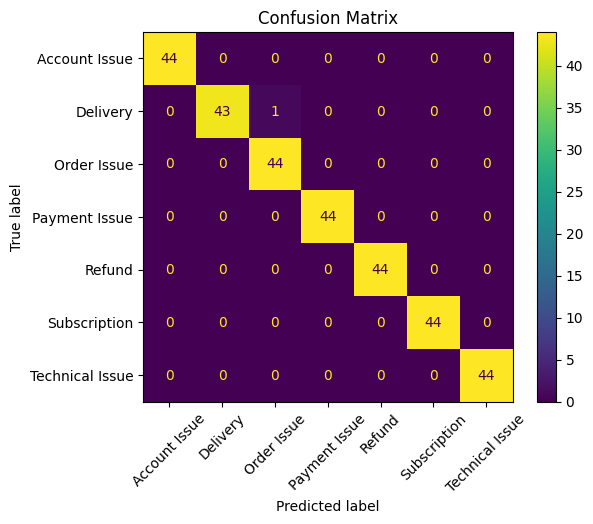

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train_tfidf, y_train)
rf_pred = rf_model.predict(X_test_tfidf)
print("Random Forest Accuracy:",accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 1.0


In [37]:
print(classification_report(y_test, rf_pred))

                 precision    recall  f1-score   support

  Account Issue       1.00      1.00      1.00        44
       Delivery       1.00      1.00      1.00        44
    Order Issue       1.00      1.00      1.00        44
  Payment Issue       1.00      1.00      1.00        44
         Refund       1.00      1.00      1.00        44
   Subscription       1.00      1.00      1.00        44
Technical Issue       1.00      1.00      1.00        44

       accuracy                           1.00       308
      macro avg       1.00      1.00      1.00       308
   weighted avg       1.00      1.00      1.00       308



RandomForestClassifier is the best model compare to logistic regression model

In [54]:
def classify_ticket(ticket):
    ticket_tfidf = tfidf.transform([ticket])
    prediction = rf_model.predict(ticket_tfidf)
    return prediction[0]

In [55]:
ticket = "My credit card payment was declined"
result = classify_ticket(ticket)
print("Predicted Category:", result)

Predicted Category: Payment Issue


In [57]:
ticket = "I forgot my account password"
print("Predicted Category:",classify_ticket(ticket))

Predicted Category: Account Issue


In [61]:
def classify_ticket_(ticket):
    ticket_tfidf = tfidf.transform([ticket])
    prediction = rf_model.predict(ticket_tfidf)[0]
    probabilities = rf_model.predict_proba(ticket_tfidf)[0]
    confidence = max(probabilities)
    return prediction, confidence

In [64]:
ticket = "I forgot my account password"
category, confidence = classify_ticket_(ticket)
print("Category:", category)
print("Confidence:", confidence)

Category: Account Issue
Confidence: 0.99


In [65]:
print("Confidence:",confidence * 100, "%")

Confidence: 99.0 %
